In [90]:
import torch
import matplotlib.pyplot as plt 

import numpy as np
from PIL import Image
from pathlib import Path

from torch.utils.data import DataLoader

from torchvision import datasets, transforms, models



In [91]:
# def set_seeds():
#     SEED_VALUE = 42 
#     torch.manual_seed(SEED_VALUE)
    


### Data inpection

In [92]:
DATA_DIR = Path("../data/Otoscopic_Data")
#print(data_root.exists())

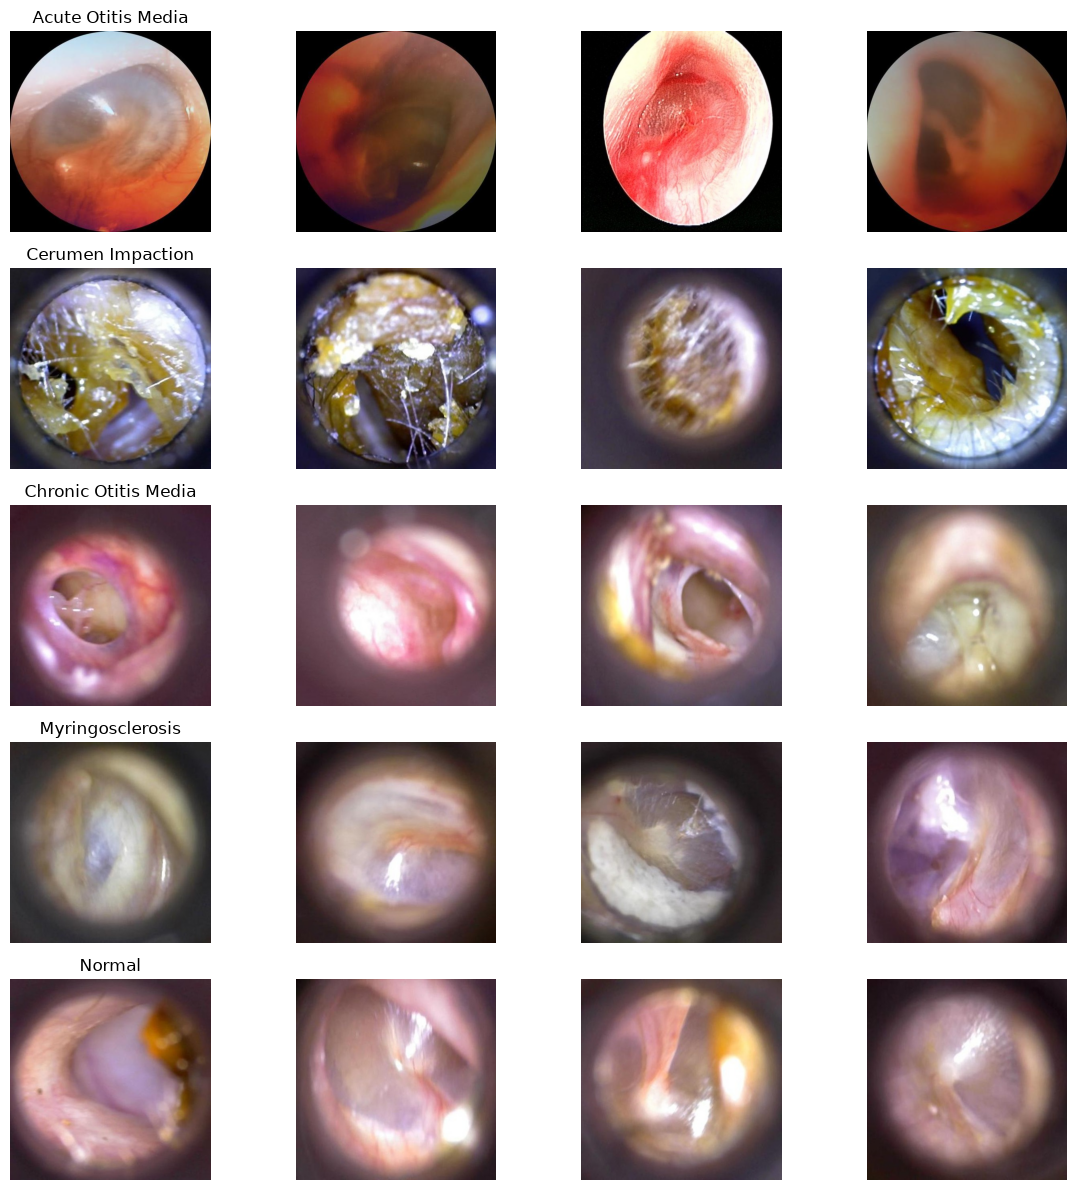

In [93]:
class_names = [
    "Acute Otitis Media",
    "Cerumen Impaction",
    "Chronic Otitis Media",
    "Myringosclerosis",
    "Normal",
]

num_images_per_class = 4

fig, axes = plt.subplots(
    len(class_names),
    num_images_per_class,
    figsize=(12, 12)
)

for row, class_name in enumerate(class_names):
    image_paths = list(
        (DATA_DIR / class_name).rglob("*.jpg")
    )

    for col, image_path in enumerate(
        image_paths[:num_images_per_class]
    ):
        image = Image.open(image_path)

        axes[row, col].imshow(image)
        axes[row, col].axis("off")


        if col == 0:
            axes[row, col].set_title(class_name)

plt.tight_layout()
plt.show()

In [94]:
all_image_paths = list(DATA_DIR.rglob("*.jpg"))

sizes = []

for path in all_image_paths:
    with Image.open(path) as img:
        sizes.append(img.size)

print("Number of images:", len(sizes))
print("Number of unique sizes:", len(set(sizes)))
# print("First 10 unique sizes:", list(set(sizes))[:10])
from collections import Counter

size_counts = Counter(sizes)

for size, count in size_counts.most_common(10):
    print(size, count)

Number of images: 3000
Number of unique sizes: 1
(500, 500) 3000


### Split train valid test

In [95]:
full_dataset = datasets.ImageFolder(
    root=DATA_DIR
)


print(full_dataset.classes)
print(full_dataset.class_to_idx)
print(len(full_dataset))

['Acute Otitis Media', 'Cerumen Impaction', 'Chronic Otitis Media', 'Myringosclerosis', 'Normal']
{'Acute Otitis Media': 0, 'Cerumen Impaction': 1, 'Chronic Otitis Media': 2, 'Myringosclerosis': 3, 'Normal': 4}
3000


In [96]:
from sklearn.model_selection import train_test_split
targets = full_dataset.targets
all_indices = list(range(len(full_dataset)))

train_indices, temporary_indices = train_test_split(
    all_indices,
    test_size=0.30,
    random_state=42,
    stratify=targets,
)


temporary_targets = [targets[index] for index in temporary_indices]

valid_indices, test_indices = train_test_split(
    temporary_indices,
    test_size=0.50,
    random_state=42,
    stratify=temporary_targets,
)

### Training and dataset configs

In [97]:
# class DatasetConfig:

# class TrainingConfig:

In [98]:
#using imagenet pretrained expected mean and std values for normalization
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD = [0.229, 0.224, 0.225]

DEFINE TRANSFORMS

In [99]:
# Training and dataset configs
# Define transforms for the training, validation, and testing sets

train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(IMG_MEAN, IMG_STD)
    ])
valid_transform =  transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(IMG_MEAN, IMG_STD)
    ])
test_transform =  transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(IMG_MEAN, IMG_STD)
  ])

# train_dataset = datasets.ImageFolder(root=DATA_DIR / "train", transform=train_transform)
# valid_dataset = datasets.ImageFolder(root=DATA_DIR / "valid", transform=valid_transform)
# test_dataset = datasets.ImageFolder(root=DATA_DIR / "test", transform=test_transform)


READ THE DATASET

In [101]:
train_full_dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=train_transform,
)

valid_full_dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=valid_transform,
)

test_full_dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=test_transform,
)

from torch.utils.data import Subset

train_dataset = Subset(train_full_dataset, train_indices)
valid_dataset = Subset(valid_full_dataset, valid_indices)
test_dataset = Subset(test_full_dataset, test_indices)

CREATE DATA LOADERS

In [102]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
)

In [103]:
print("Training images:", len(train_dataset))
print("Validation images:", len(valid_dataset))
print("Test images:", len(test_dataset))

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Training images: 2100
Validation images: 450
Test images: 450
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


In [104]:
print(train_full_dataset.classes)
print(train_full_dataset.class_to_idx)

['Acute Otitis Media', 'Cerumen Impaction', 'Chronic Otitis Media', 'Myringosclerosis', 'Normal']
{'Acute Otitis Media': 0, 'Cerumen Impaction': 1, 'Chronic Otitis Media': 2, 'Myringosclerosis': 3, 'Normal': 4}


## TRAIN

In [105]:
	
# Load the pre-trained ResNet18 <model.

from torchvision.models import resnet18, ResNet18_Weights
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)


In [106]:
print(model.fc)

Linear(in_features=512, out_features=1000, bias=True)


REPLACE FINAL FC layer WITH CORRECT NUMBER OF OUTPUT CLASSES

In [107]:
# Freeze all pretrained ResNet parameters
for parameter in model.parameters():
    parameter.requires_grad = False

num_classes = len(train_full_dataset.classes) #AKA 5 classes
# Replace the final fully connected layer with a new one that has the correct number of output classes
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)


In [108]:
print(model.fc)

for name, parameter in model.named_parameters():
    print(name, parameter.requires_grad)

Linear(in_features=512, out_features=5, bias=True)
conv1.weight False
bn1.weight False
bn1.bias False
layer1.0.conv1.weight False
layer1.0.bn1.weight False
layer1.0.bn1.bias False
layer1.0.conv2.weight False
layer1.0.bn2.weight False
layer1.0.bn2.bias False
layer1.1.conv1.weight False
layer1.1.bn1.weight False
layer1.1.bn1.bias False
layer1.1.conv2.weight False
layer1.1.bn2.weight False
layer1.1.bn2.bias False
layer2.0.conv1.weight False
layer2.0.bn1.weight False
layer2.0.bn1.bias False
layer2.0.conv2.weight False
layer2.0.bn2.weight False
layer2.0.bn2.bias False
layer2.0.downsample.0.weight False
layer2.0.downsample.1.weight False
layer2.0.downsample.1.bias False
layer2.1.conv1.weight False
layer2.1.bn1.weight False
layer2.1.bn1.bias False
layer2.1.conv2.weight False
layer2.1.bn2.weight False
layer2.1.bn2.bias False
layer3.0.conv1.weight False
layer3.0.bn1.weight False
layer3.0.bn1.bias False
layer3.0.conv2.weight False
layer3.0.bn2.weight False
layer3.0.bn2.bias False
layer3.0.downsa

TRAINING PIPELINE

In [109]:
import os


def create_checkpoint_dir(checkpoint_dir):

    # Create a new checkpoint directory every time.
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)

    print(f"Checkpoint directory: {checkpoint_dir}")
    return checkpoint_dir

SET UP TRAINING MODE

In [ ]:
def train(model,optimizer,train_loader,device):
    #model.train()
    model.eval()
    model.fc.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = torch.nn.functional.cross_entropy(outputs, labels)

        loss.backward()
        optimizer.step()

        # Sample-weighted loss
        running_loss += loss.item() * images.size(0)

        # Calculate predictions
        predicted_labels = outputs.argmax(dim=1)

        # Count correct predictions
        correct_predictions += (
            predicted_labels == labels
        ).sum().item()

        # Count samples
        total_samples += images.size(0)

    #avg loss over the entire epoch
    # epoch_loss = running_loss / len(train_loader)

    epoch_loss = running_loss / total_samples
    accuracy = correct_predictions / total_samples


    return epoch_loss, accuracy

In [111]:
def save_checkpoint(
    model,
    optimizer,
    epoch,
    valid_loss,
    valid_accuracy,
    checkpoint_dir
):
    checkpoint_path = os.path.join(
        checkpoint_dir,
        "best_model.pth"
    )

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "valid_loss": valid_loss,
            "valid_accuracy": valid_accuracy,
            "class_names": train_full_dataset.classes,
        },
        checkpoint_path
    )

    print(f"Best checkpoint saved at: {checkpoint_path}")

In [112]:
from torch.nn.functional import cross_entropy
def validate(model, valid_loader, device):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = cross_entropy(outputs, labels)
            running_loss += loss.item() * images.size(0)

            predicted_labels = outputs.argmax(dim=1)

            correct_predictions += (
                predicted_labels == labels
            ).sum().item()

            total_samples += images.size(0)

    epoch_loss = running_loss / total_samples
    accuracy = correct_predictions / total_samples

    return epoch_loss, accuracy

In [113]:
def main():
   #device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    model.to(device)

    #optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001) # bc training final layer only

    checkpoint_dir = create_checkpoint_dir("checkpoints")

    #num_epochs = 10
    num_epochs = 10 #FOR TESTING PURPOSES
    best_valid_loss = float("inf")

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model, optimizer, train_loader, device)
        valid_loss, valid_accuracy = validate(model, valid_loader, device)

        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.4f}, "
              f"Train Accuracy: {train_accuracy:.4f}, "
              f"Valid Loss: {valid_loss:.4f}, "
              f"Valid Accuracy: {valid_accuracy:.4f}")

        #save_checkpoint(model, optimizer, epoch + 1, checkpoint_dir)    
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss

            save_checkpoint(
                model=model,
                optimizer=optimizer,
                epoch=epoch + 1,
                valid_loss=valid_loss,
                valid_accuracy=valid_accuracy,
                checkpoint_dir=checkpoint_dir
            )
            

PRE RUN TEST

In [114]:
# import torch

print("PyTorch version:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())

PyTorch version: 2.13.0
MPS available: True
MPS built: True


In [115]:
main()

Checkpoint directory: checkpoints
Epoch [1/10], Train Loss: 0.7915, Train Accuracy: 0.7362, Valid Loss: 0.3829, Valid Accuracy: 0.9000
Best checkpoint saved at: checkpoints/best_model.pth
Epoch [2/10], Train Loss: 0.3194, Train Accuracy: 0.9195, Valid Loss: 0.2673, Valid Accuracy: 0.9222
Best checkpoint saved at: checkpoints/best_model.pth
Epoch [3/10], Train Loss: 0.2395, Train Accuracy: 0.9376, Valid Loss: 0.1837, Valid Accuracy: 0.9733
Best checkpoint saved at: checkpoints/best_model.pth
Epoch [4/10], Train Loss: 0.1868, Train Accuracy: 0.9505, Valid Loss: 0.1544, Valid Accuracy: 0.9733
Best checkpoint saved at: checkpoints/best_model.pth
Epoch [5/10], Train Loss: 0.1597, Train Accuracy: 0.9624, Valid Loss: 0.1553, Valid Accuracy: 0.9422
Epoch [6/10], Train Loss: 0.1406, Train Accuracy: 0.9662, Valid Loss: 0.1250, Valid Accuracy: 0.9622
Best checkpoint saved at: checkpoints/best_model.pth
Epoch [7/10], Train Loss: 0.1243, Train Accuracy: 0.9705, Valid Loss: 0.1104, Valid Accuracy: 0

### EVALUATE

In [117]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

 

checkpoint_path = "checkpoints/best_model.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
print(f"Validation loss: {checkpoint['valid_loss']:.4f}")
print(f"Validation accuracy: {checkpoint['valid_accuracy']:.4f}")

Loaded checkpoint from epoch 9
Validation loss: 0.0975
Validation accuracy: 0.9711


In [118]:
test_loss, test_accuracy = validate(
    model,
    test_loader,
    device
)

print(
    f"Test Loss: {test_loss:.4f}, "
    f"Test Accuracy: {test_accuracy:.4f}"
)

Test Loss: 0.1150, Test Accuracy: 0.9756


In [119]:
import matplotlib.pyplot as plt
import torch

# ImageNet normalization values used by pretrained ResNet18
IMG_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMG_STD = torch.tensor([0.229, 0.224, 0.225])


def denormalize_image(image):
    """
    Reverse ImageNet normalization for visualization.

    image shape: [channels, height, width]
    """
    image = image.cpu()

    mean = IMG_MEAN[:, None, None]
    std = IMG_STD[:, None, None]

    image = image * std + mean

    # Keep pixel values in the valid display range
    return image.clamp(0, 1)


def show_test_predictions(
    model,
    test_loader,
    device,
    class_names,
    number_of_images=12
):
    model.eval()

    # Get one batch from the test loader
    images, labels = next(iter(test_loader))

    images = images.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        predicted_labels = outputs.argmax(dim=1)

    number_of_images = min(number_of_images, images.size(0))

    columns = 4
    rows = (number_of_images + columns - 1) // columns

    plt.figure(figsize=(14, 3.5 * rows))

    for index in range(number_of_images):
        image = denormalize_image(images[index])

        # Convert from [C, H, W] to [H, W, C]
        image = image.permute(1, 2, 0)

        true_index = labels[index].item()
        predicted_index = predicted_labels[index].item()

        true_name = class_names[true_index]
        predicted_name = class_names[predicted_index]

        correct = true_index == predicted_index
        result = "Correct" if correct else "Incorrect"

        plt.subplot(rows, columns, index + 1)
        plt.imshow(image)
        plt.title(
            f"{result}\n"
            f"True: {true_name}\n"
            f"Predicted: {predicted_name}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [120]:
import matplotlib.pyplot as plt
import torch

# ImageNet normalization values used by pretrained ResNet18
IMG_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMG_STD = torch.tensor([0.229, 0.224, 0.225])


def denormalize_image(image):
    """
    Reverse ImageNet normalization for visualization.

    image shape: [channels, height, width]
    """
    image = image.cpu()

    mean = IMG_MEAN[:, None, None]
    std = IMG_STD[:, None, None]

    image = image * std + mean

    # Keep pixel values in the valid display range
    return image.clamp(0, 1)


def show_test_predictions(
    model,
    test_loader,
    device,
    class_names,
    number_of_images=12
):
    model.eval()

    # Get one batch from the test loader
    images, labels = next(iter(test_loader))

    images = images.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        predicted_labels = outputs.argmax(dim=1)

    number_of_images = min(number_of_images, images.size(0))

    columns = 4
    rows = (number_of_images + columns - 1) // columns

    plt.figure(figsize=(14, 3.5 * rows))

    for index in range(number_of_images):
        image = denormalize_image(images[index])

        # Convert from [C, H, W] to [H, W, C]
        image = image.permute(1, 2, 0)

        true_index = labels[index].item()
        predicted_index = predicted_labels[index].item()

        true_name = class_names[true_index]
        predicted_name = class_names[predicted_index]

        correct = true_index == predicted_index
        result = "Correct" if correct else "Incorrect"

        plt.subplot(rows, columns, index + 1)
        plt.imshow(image)
        plt.title(
            f"{result}\n"
            f"True: {true_name}\n"
            f"Predicted: {predicted_name}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

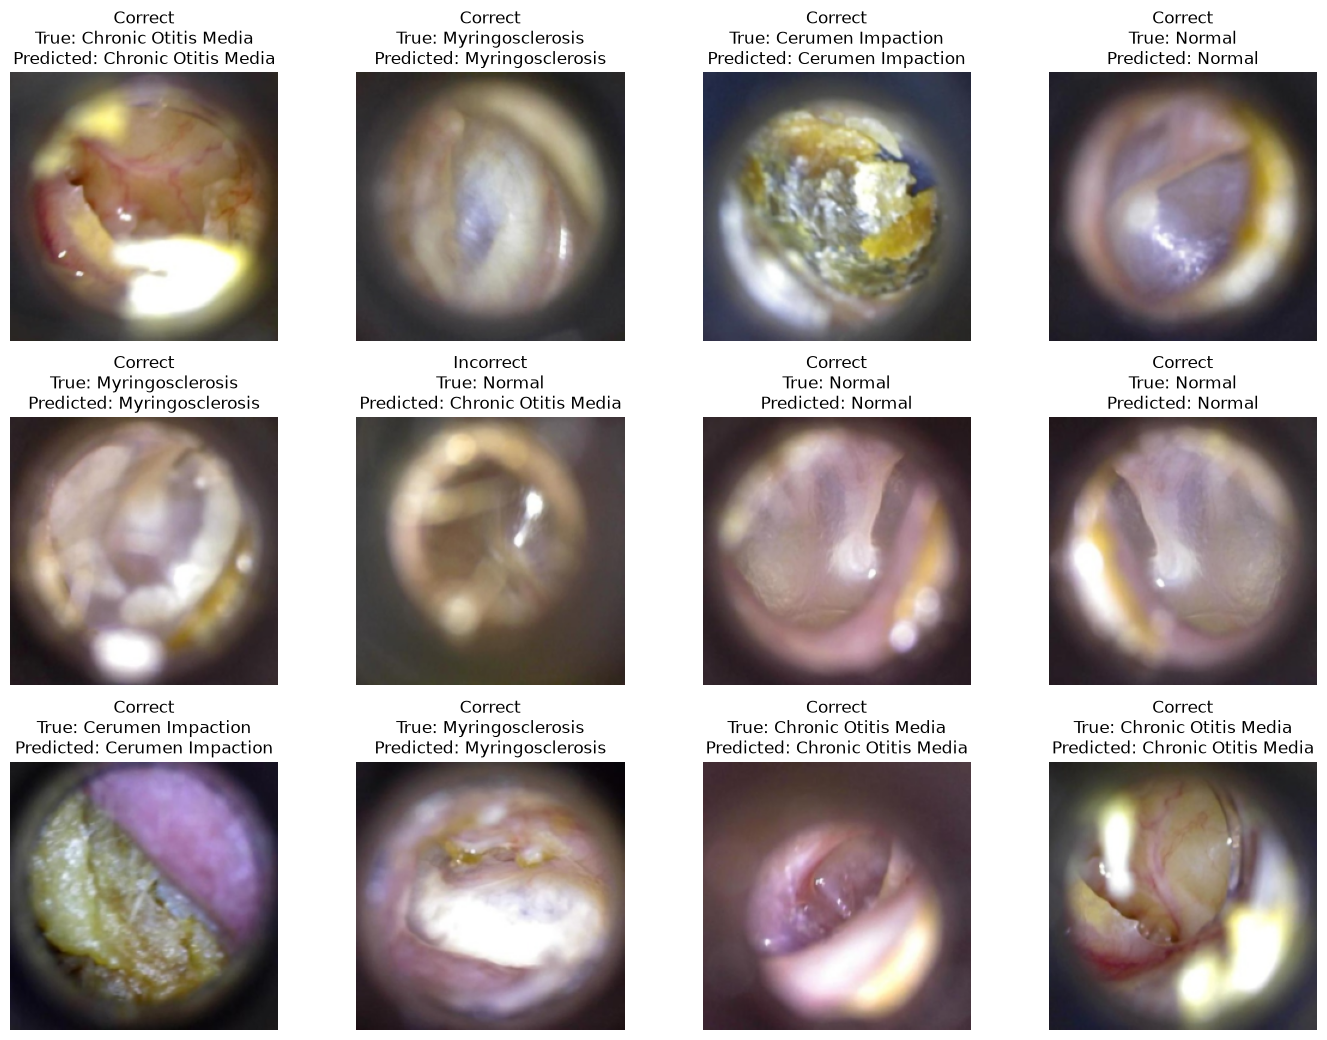

In [123]:
class_names = full_dataset.classes

show_test_predictions(
    model=model,
    test_loader=test_loader,
    device=device,
    class_names=class_names,
    number_of_images=12
)

SANITY CHECK

In [ ]:
# from torchvision.models import resnet18, ResNet18_Weights

# # Create a completely separate model
# baseline_model = resnet18(
#     weights=ResNet18_Weights.DEFAULT
# )

# # Freeze pretrained backbone
# for parameter in baseline_model.parameters():
#     parameter.requires_grad = False

# # Add a fresh, randomly initialized 5-class classification layer
# baseline_model.fc = torch.nn.Linear(
#     baseline_model.fc.in_features,
#     num_classes
# )

# baseline_model.to(device)

# # Evaluate immediately — NO TRAINING
# initial_loss, initial_accuracy = validate(
#     baseline_model,
#     valid_loader,
#     device
# )

# print(
#     f"Before training — "
#     f"Valid Loss: {initial_loss:.4f}, "
#     f"Valid Accuracy: {initial_accuracy:.4f}"
# )

Before training — Valid Loss: 1.9419, Valid Accuracy: 0.1867


### Grad CAM analysis

In [125]:
checkpoint = torch.load(
    "checkpoints/best_model.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")

Loaded checkpoint from epoch 9


In [126]:
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [129]:
IMG_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMG_STD = torch.tensor([0.229, 0.224, 0.225])


def denormalize_image(image):
    image = image.detach().cpu()

    mean = IMG_MEAN[:, None, None]
    std = IMG_STD[:, None, None]

    image = image * std + mean
    return image.clamp(0, 1)


def show_gradcam(
    model,
    image,
    true_label,
    class_names,
    device
):
    model.eval()

    # Add batch dimension: [3, 224, 224] -> [1, 3, 224, 224]
    #input_tensor = image.unsqueeze(0).to(device)
    input_tensor = (
        image.unsqueeze(0)
        .to(device)
        .clone()
        .detach()
        .requires_grad_(True)
    )


    with torch.no_grad():
        outputs = model(input_tensor)
        predicted_index = outputs.argmax(dim=1).item()

    # Last convolutional block of ResNet18
    target_layers = [model.layer4[-1]]

    # Generate Grad-CAM for the predicted class
    targets = [
        ClassifierOutputTarget(predicted_index)
    ]

    with GradCAM(
        model=model,
        target_layers=target_layers
    ) as cam:
        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets
        )[0]

    # Reverse normalization for display
    display_image = denormalize_image(image)
    display_image = display_image.permute(1, 2, 0).numpy()

    # Overlay heatmap onto the original image
    cam_overlay = show_cam_on_image(
        display_image.astype(np.float32),
        grayscale_cam,
        use_rgb=True
    )

    true_name = class_names[true_label]
    predicted_name = class_names[predicted_index]

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(display_image)
    plt.title(f"Original\nTrue: {true_name}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cam_overlay)
    plt.title(f"Grad-CAM\nPredicted: {predicted_name}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

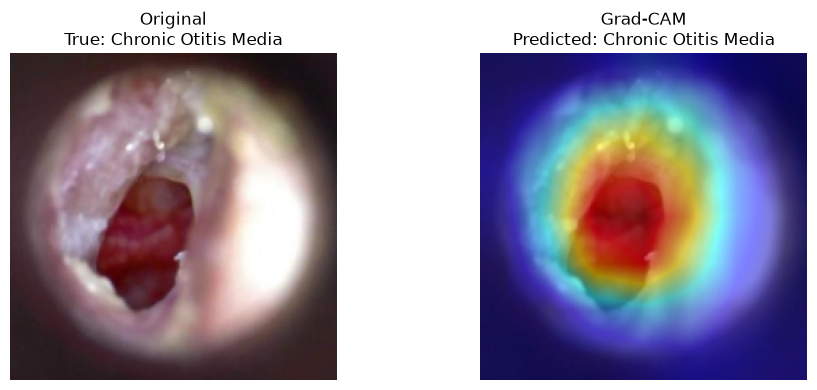

In [140]:
test_image, test_label = test_dataset[190]

show_gradcam(
    model=model,
    image=test_image,
    true_label=test_label,
    class_names=full_dataset.classes,
    device=device
)

